Dataset shape: (150, 4)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3333 - loss: 1.4690  
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3333 - loss: 1.3549 
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2583 - loss: 1.2580 
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0083 - loss: 1.1932 
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1500 - loss: 1.1443     
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2833 - loss: 1.1001
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3000 - loss: 1.0689
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3250 - loss: 1.0452 
Epoch 9/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3250 - loss: 1.0231 
Epoch 10/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3250 - loss: 0.9994 
Epoch 11/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3250 - loss: 0.9756 
Epoch 12/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3250 - loss: 0.9

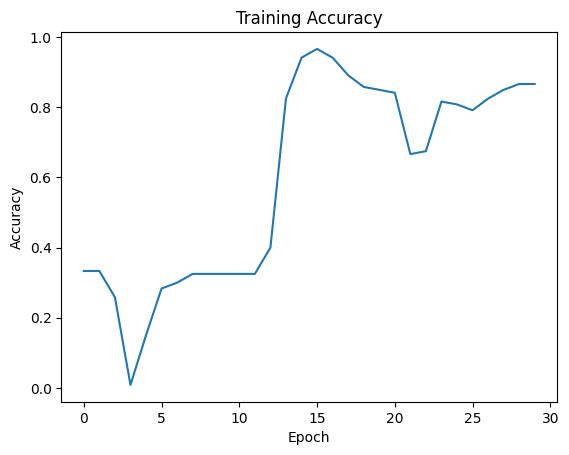

In [5]:
# ------------------------------------------
# Experiment 3:
# ------------------------------------------

# 1. Import libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 2. Load dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Dataset shape:", X.shape)

# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 4. Create neural network with increased neurons

model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        32,                  # Increased from 16 to 32 neurons
        activation="relu",
        input_shape=(4,)
    ),
    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),
    tf.keras.layers.Dense(
        3,
        activation="softmax"
    )
])

# 5. Compile model
model.compile(
    optimizer="adam",       # Optimizer remains unchanged
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 6. Display architecture
model.summary()

# 7. Train model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_split=0.0
)

# 8. Evaluate model
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

# 9. Make predictions
predictions = model.predict(X_test[:4])
predicted_classes = predictions.argmax(axis=1)

print("\nPredicted classes:", predicted_classes)
print("Actual classes:   ", y_test[:5])

# 10. Plot training accuracy
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

Dataset shape: (150, 4)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,067 (8.07 KB)

 Trainable params: 2,067 (8.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.2812 - loss: 1.1703 - val_accuracy: 0.5000 - val_loss: 0.9745
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2812 - loss: 1.1064 - val_accuracy: 0.5000 - val_loss: 0.9717
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2812 - loss: 1.0736 - val_accuracy: 0.5000 - val_loss: 0.9622
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2917 - loss: 1.0406 - val_accuracy: 0.5000 - val_loss: 0.9445
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2917 - loss: 1.0126 - val_accuracy: 0.5000 - val_loss: 0.9201
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2917 - loss: 0.9922 - val_accuracy: 0.5000 - val_loss: 0.8910
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2812 - loss: 0.9731 - val_accuracy: 0.5000 - val_loss: 0.8603
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2812 - loss: 0.9501 - val_accuracy: 0.5000 - val_loss: 0.8387

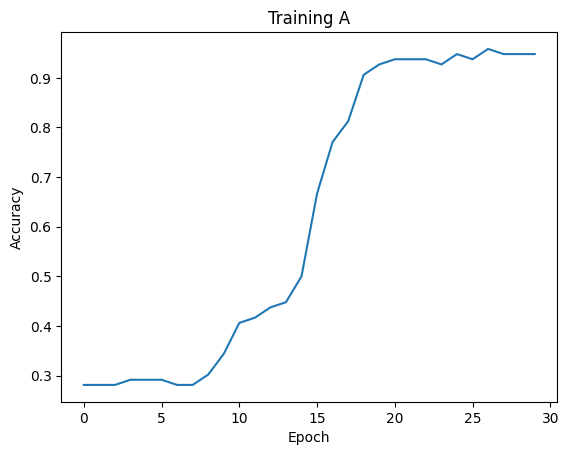

In [6]:
# 1. Import libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 2. Load dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Dataset shape:", X.shape)


# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 4. Create neural network with increased hidden layers
model = tf.keras.Sequential([
    # Hidden Layer 1
    tf.keras.layers.Dense(
        32,
        activation="relu",
        input_shape=(4,)
    ),

    # Hidden Layer 2
    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    # Hidden Layer 3
    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    # Hidden Layer 4
    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    # Output Layer
    tf.keras.layers.Dense(
        3,
        activation="softmax"
    )
])


# 5. Compile model
model.compile(
    optimizer="adam",   # Optimizer unchanged
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# 6. Display architecture
model.summary()

# 7. Train model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_split=0.2
)

# 8. Evaluate model
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)


# 9. Make predictions
predictions = model.predict(X_test[:5])
predicted_classes = predictions.argmax(axis=1)

print("\nPredicted classes:", predicted_classes)
print("Actual classes:   ", y_test[:5])


# 10. Plot training accuracy
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training A")
plt.show()